<a href="https://colab.research.google.com/github/nicolb21/TelecomX_parte2_Latam/blob/main/Telecom_X__Parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Analisis Churn  de clientes Telecom X Latam

🎯 Misión

Tu nueva misión es desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

La empresa quiere anticiparse al problema de la cancelación, y te corresponde a ti construir un pipeline robusto para esta etapa inicial de modelado.


🧠 Objetivos del Desafío

Preparar los datos para el modelado (tratamiento, codificación, normalización).

Realizar análisis de correlación y selección de variables.

Entrenar dos o más modelos de clasificación.

Evaluar el rendimiento de los modelos con métricas.

Interpretar los resultados, incluyendo la importancia de las variables.

Crear una conclusión estratégica señalando los principales factores que influyen en la cancelación.



In [ ]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
import yellowbrick

print(f'Versión de pandas: {pd.__version__}')
print(f'Versión de numpy: {np.__version__}')
print(f'Versión de scikit-learn (sklearn): {sklearn.__version__}')
print(f'Versión de seaborn: {sns.__version__}')
print(f'Versión de yellowbrick: {yellowbrick.__version__}')

Versión de pandas: 2.2.2
Versión de numpy: 2.0.2
Versión de scikit-learn (sklearn): 1.6.1
Versión de seaborn: 0.13.2
Versión de yellowbrick: 1.5


In [ ]:
datos = pd.read_csv("/content/datos_tratados.csv")

#ANALISIS EXPLORATORIO ANALITICO

In [ ]:
datos.shape

(7032, 22)

In [ ]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customerID           7032 non-null   object 
 1   Churn                7032 non-null   int64  
 2   gender               7032 non-null   object 
 3   SeniorCitizen        7032 non-null   int64  
 4   Partner              7032 non-null   int64  
 5   Dependents           7032 non-null   int64  
 6   Antiguedad_en_meses  7032 non-null   int64  
 7   PhoneService         7032 non-null   int64  
 8   MultipleLines        7032 non-null   object 
 9   InternetService      7032 non-null   object 
 10  OnlineSecurity       7032 non-null   object 
 11  OnlineBackup         7032 non-null   object 
 12  DeviceProtection     7032 non-null   object 
 13  TechSupport          7032 non-null   object 
 14  StreamingTV          7032 non-null   object 
 15  StreamingMovies      7032 non-null   o

#### Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `Antiguedad_en_meses`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: tipo de contrato
- `PaperlessBilling`: si el cliente prefiere recibir la factura en línea
- `PaymentMethod`: forma de pago
- `Charges.Monthly`: total de todos los servicios del cliente por mes
- `Charges.Total`: total gastado por el cliente
- `Cuentas.Diarias`: gastado diario por el cliente

In [ ]:
datos.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,Antiguedad_en_meses,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas.Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [ ]:
datos.describe()

,Churn,SeniorCitizen,Partner,Dependents,Antiguedad_en_meses,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas.Diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.162400,0.482509,0.298493,32.421786,0.903299,0.592719,64.798208,2283.300441,2.159940
std,0.441782,0.368844,0.499729,0.457629,24.545260,0.295571,0.491363,30.085974,2266.771362,1.002866
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.587500,401.450000,1.186250
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,2.345000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.862500,3794.737500,2.995417
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


In [ ]:
datos.describe(include='O') #→ nos muestra las variables categoricas

,customerID,gender,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaymentMethod
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,7032,2,3,3,3,3,3,3,3,3,3,4
top,9995-HOTOH,Male,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Electronic check
freq,1,3549,3385,3096,3497,3087,3094,3472,2809,2781,3875,2365


In [ ]:
datos['gender'].value_counts(normalize=True)*100 # me lo da en %

,proportion
gender,
Male,50.469283
Female,49.530717


Nuestra variable RESPUESTA es Churn, la cual tenemos que predecir


#ANALISIS VISUAL DE LOS DATOS

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
churn_counts = datos['Churn'].value_counts()
churn_counts

,count
Churn,
0,5163
1,1869


Hay desbalanceo entre la clase

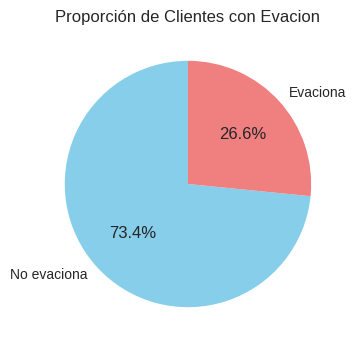

In [ ]:
plt.figure(figsize=(4, 4))
plt.pie(churn_counts, labels=['No evaciona', 'Evaciona'], autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Proporción de Clientes con Evacion')
plt.show()

##**Antiguedad de los clientes**

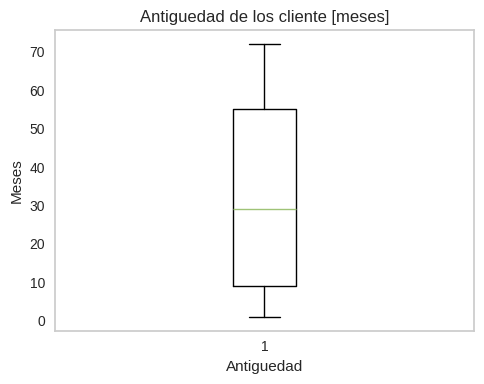

In [ ]:
plt.figure(figsize=(5,4))

plt.boxplot(datos['Antiguedad_en_meses']) #grafica de la derecha
plt.title('Antiguedad de los cliente [meses]')
plt.xlabel('Antiguedad')
plt.ylabel('Meses')
plt.grid()


plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

Antiguedad vs Costo diario

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(


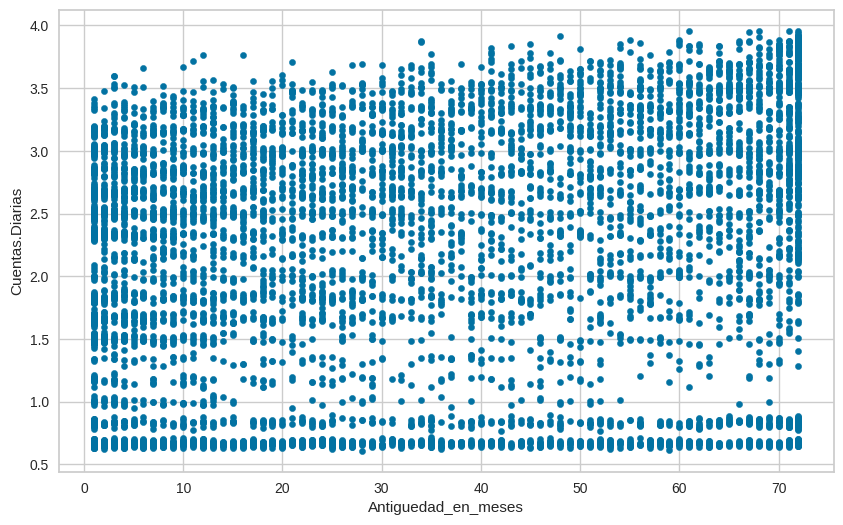

In [ ]:
datos.plot(kind='scatter',x='Antiguedad_en_meses',y='Cuentas.Diarias',figsize=(10,6));

##**Distribucion de Evacion por Genero**

In [ ]:
gender_churn_counts = datos.groupby(['gender', 'Churn']).size().unstack(fill_value=0)
display(gender_churn_counts)

Churn,0,1
gender,,
Female,2544,939
Male,2619,930


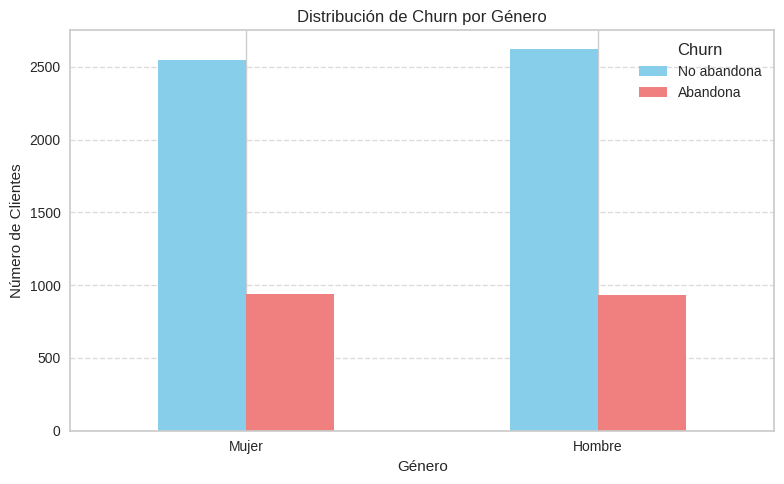

In [ ]:
gender_churn_counts.plot(kind='bar', figsize=(8, 5), rot=0, color=['skyblue', 'lightcoral'])
plt.title('Distribución de Churn por Género')
plt.xlabel('Género')
plt.ylabel('Número de Clientes')
plt.xticks(ticks=[0, 1], labels=['Mujer', 'Hombre'])
plt.legend(title='Churn', labels=['No abandona', 'Abandona'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##**Distribucion de evacion por tipo de contrato**

In [ ]:
contract_churn_counts = datos.groupby(['Contract', 'Churn']).size().unstack(fill_value=0)
display(contract_churn_counts)

Churn,0,1
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


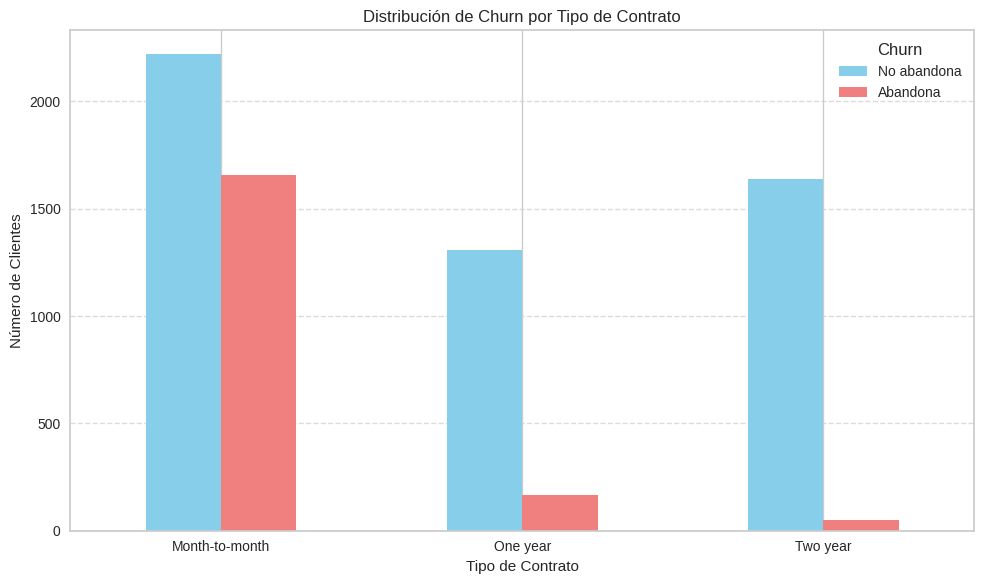

In [ ]:
contract_churn_counts.plot(kind='bar', figsize=(10, 6), rot=0, color=['skyblue', 'lightcoral'])
plt.title('Distribución de Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Número de Clientes')
plt.legend(title='Churn', labels=['No abandona', 'Abandona'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##**Distribucion de Evacion por metodo de pago**

In [ ]:
paymentmethod_churn_counts = datos.groupby(['PaymentMethod', 'Churn']).size().unstack(fill_value=0)
display(paymentmethod_churn_counts)

Churn,0,1
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


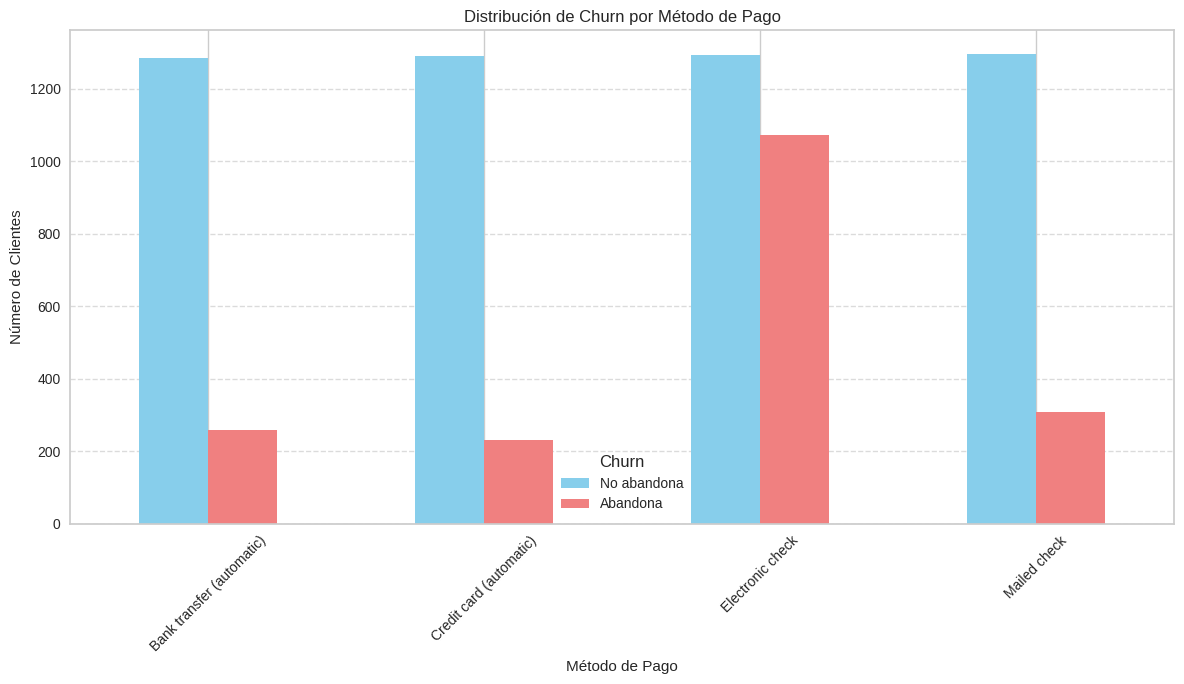

In [ ]:
paymentmethod_churn_counts.plot(kind='bar', figsize=(12, 7), rot=45, color=['skyblue', 'lightcoral'])
plt.title('Distribución de Churn por Método de Pago')
plt.xlabel('Método de Pago')
plt.ylabel('Número de Clientes')
plt.legend(title='Churn', labels=['No abandona', 'Abandona'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##**Distribucion de Antiguedad/Cargas mesuales/Cargas totales/Cargos diaros por evacion**

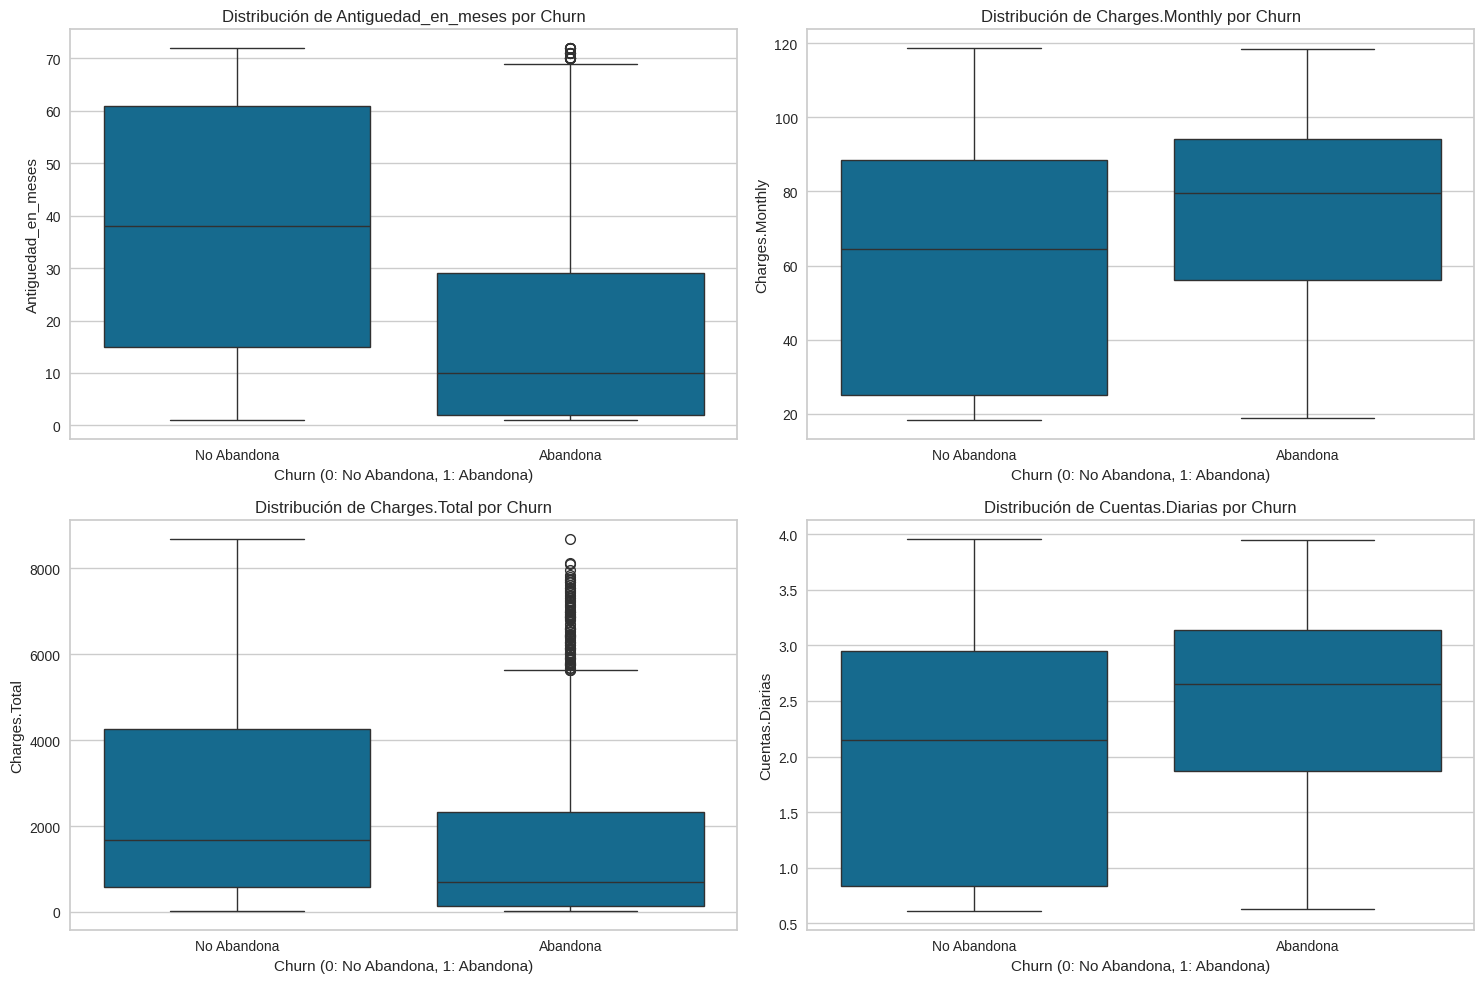

In [ ]:
numerical_cols = ['Antiguedad_en_meses', 'Charges.Monthly', 'Charges.Total', 'Cuentas.Diarias']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x='Churn', y=col, data=datos)
    plt.title(f'Distribución de {col} por Churn')
    plt.xlabel('Churn (0: No Abandona, 1: Abandona)')
    plt.ylabel(col)
    plt.xticks(ticks=[0, 1], labels=['No Abandona', 'Abandona'])
plt.tight_layout()
plt.show()

#COMO ESTAN DISTRIBUIDOS LOS DATOS

<Axes: xlabel='Charges.Total', ylabel='Count'>

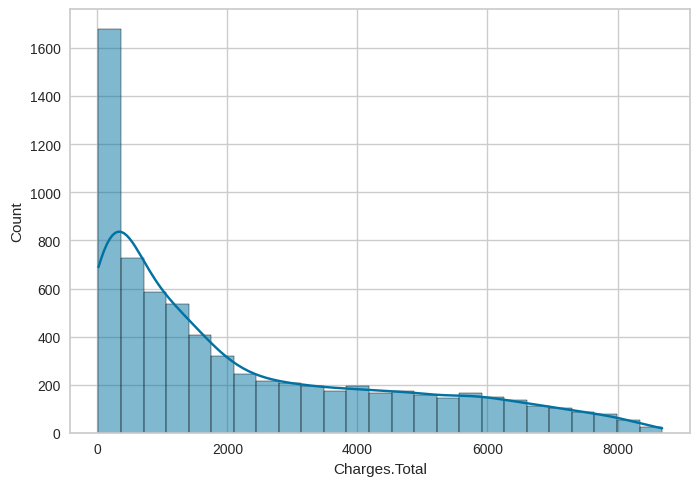

In [ ]:
sns.histplot(data=datos,x='Charges.Total',kde=True)

<Axes: xlabel='Cuentas.Diarias', ylabel='Count'>

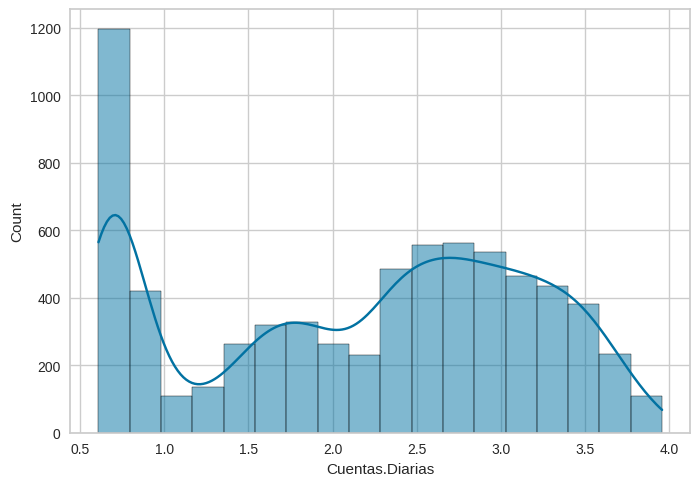

In [ ]:
sns.histplot(data=datos,x='Cuentas.Diarias',kde=True)

otra forma...

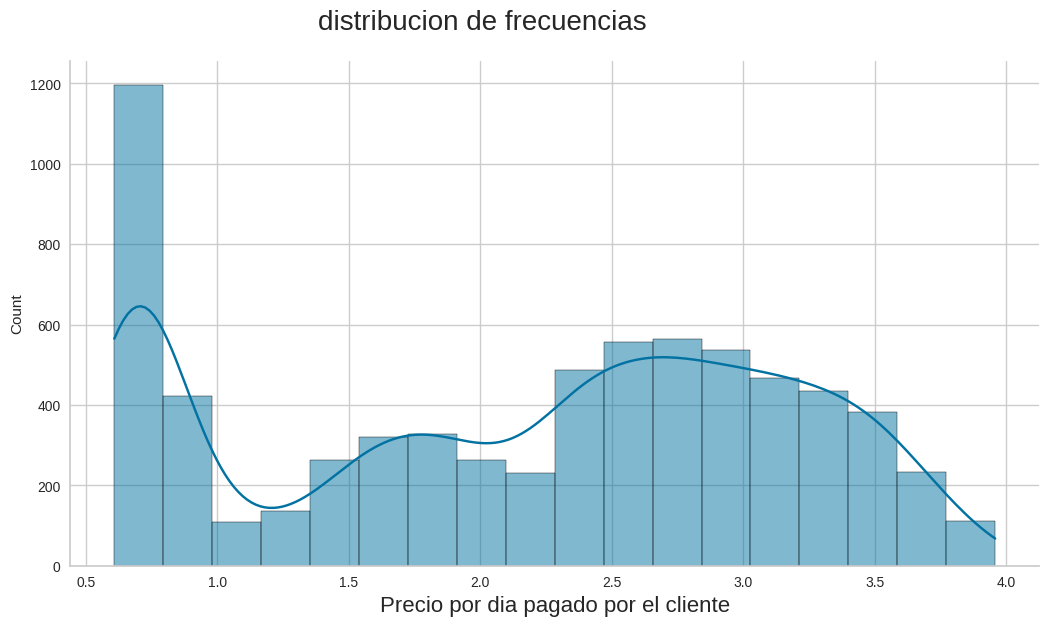

In [ ]:
ax= sns.displot(datos['Cuentas.Diarias'],kde=True)
ax.figure.set_size_inches(12,6)
ax.fig.suptitle('distribucion de frecuencias',fontsize=20,y=1.05)
ax.set_xlabels('Precio por dia pagado por el cliente',fontsize=16)
ax;

Dispersion entre las variables

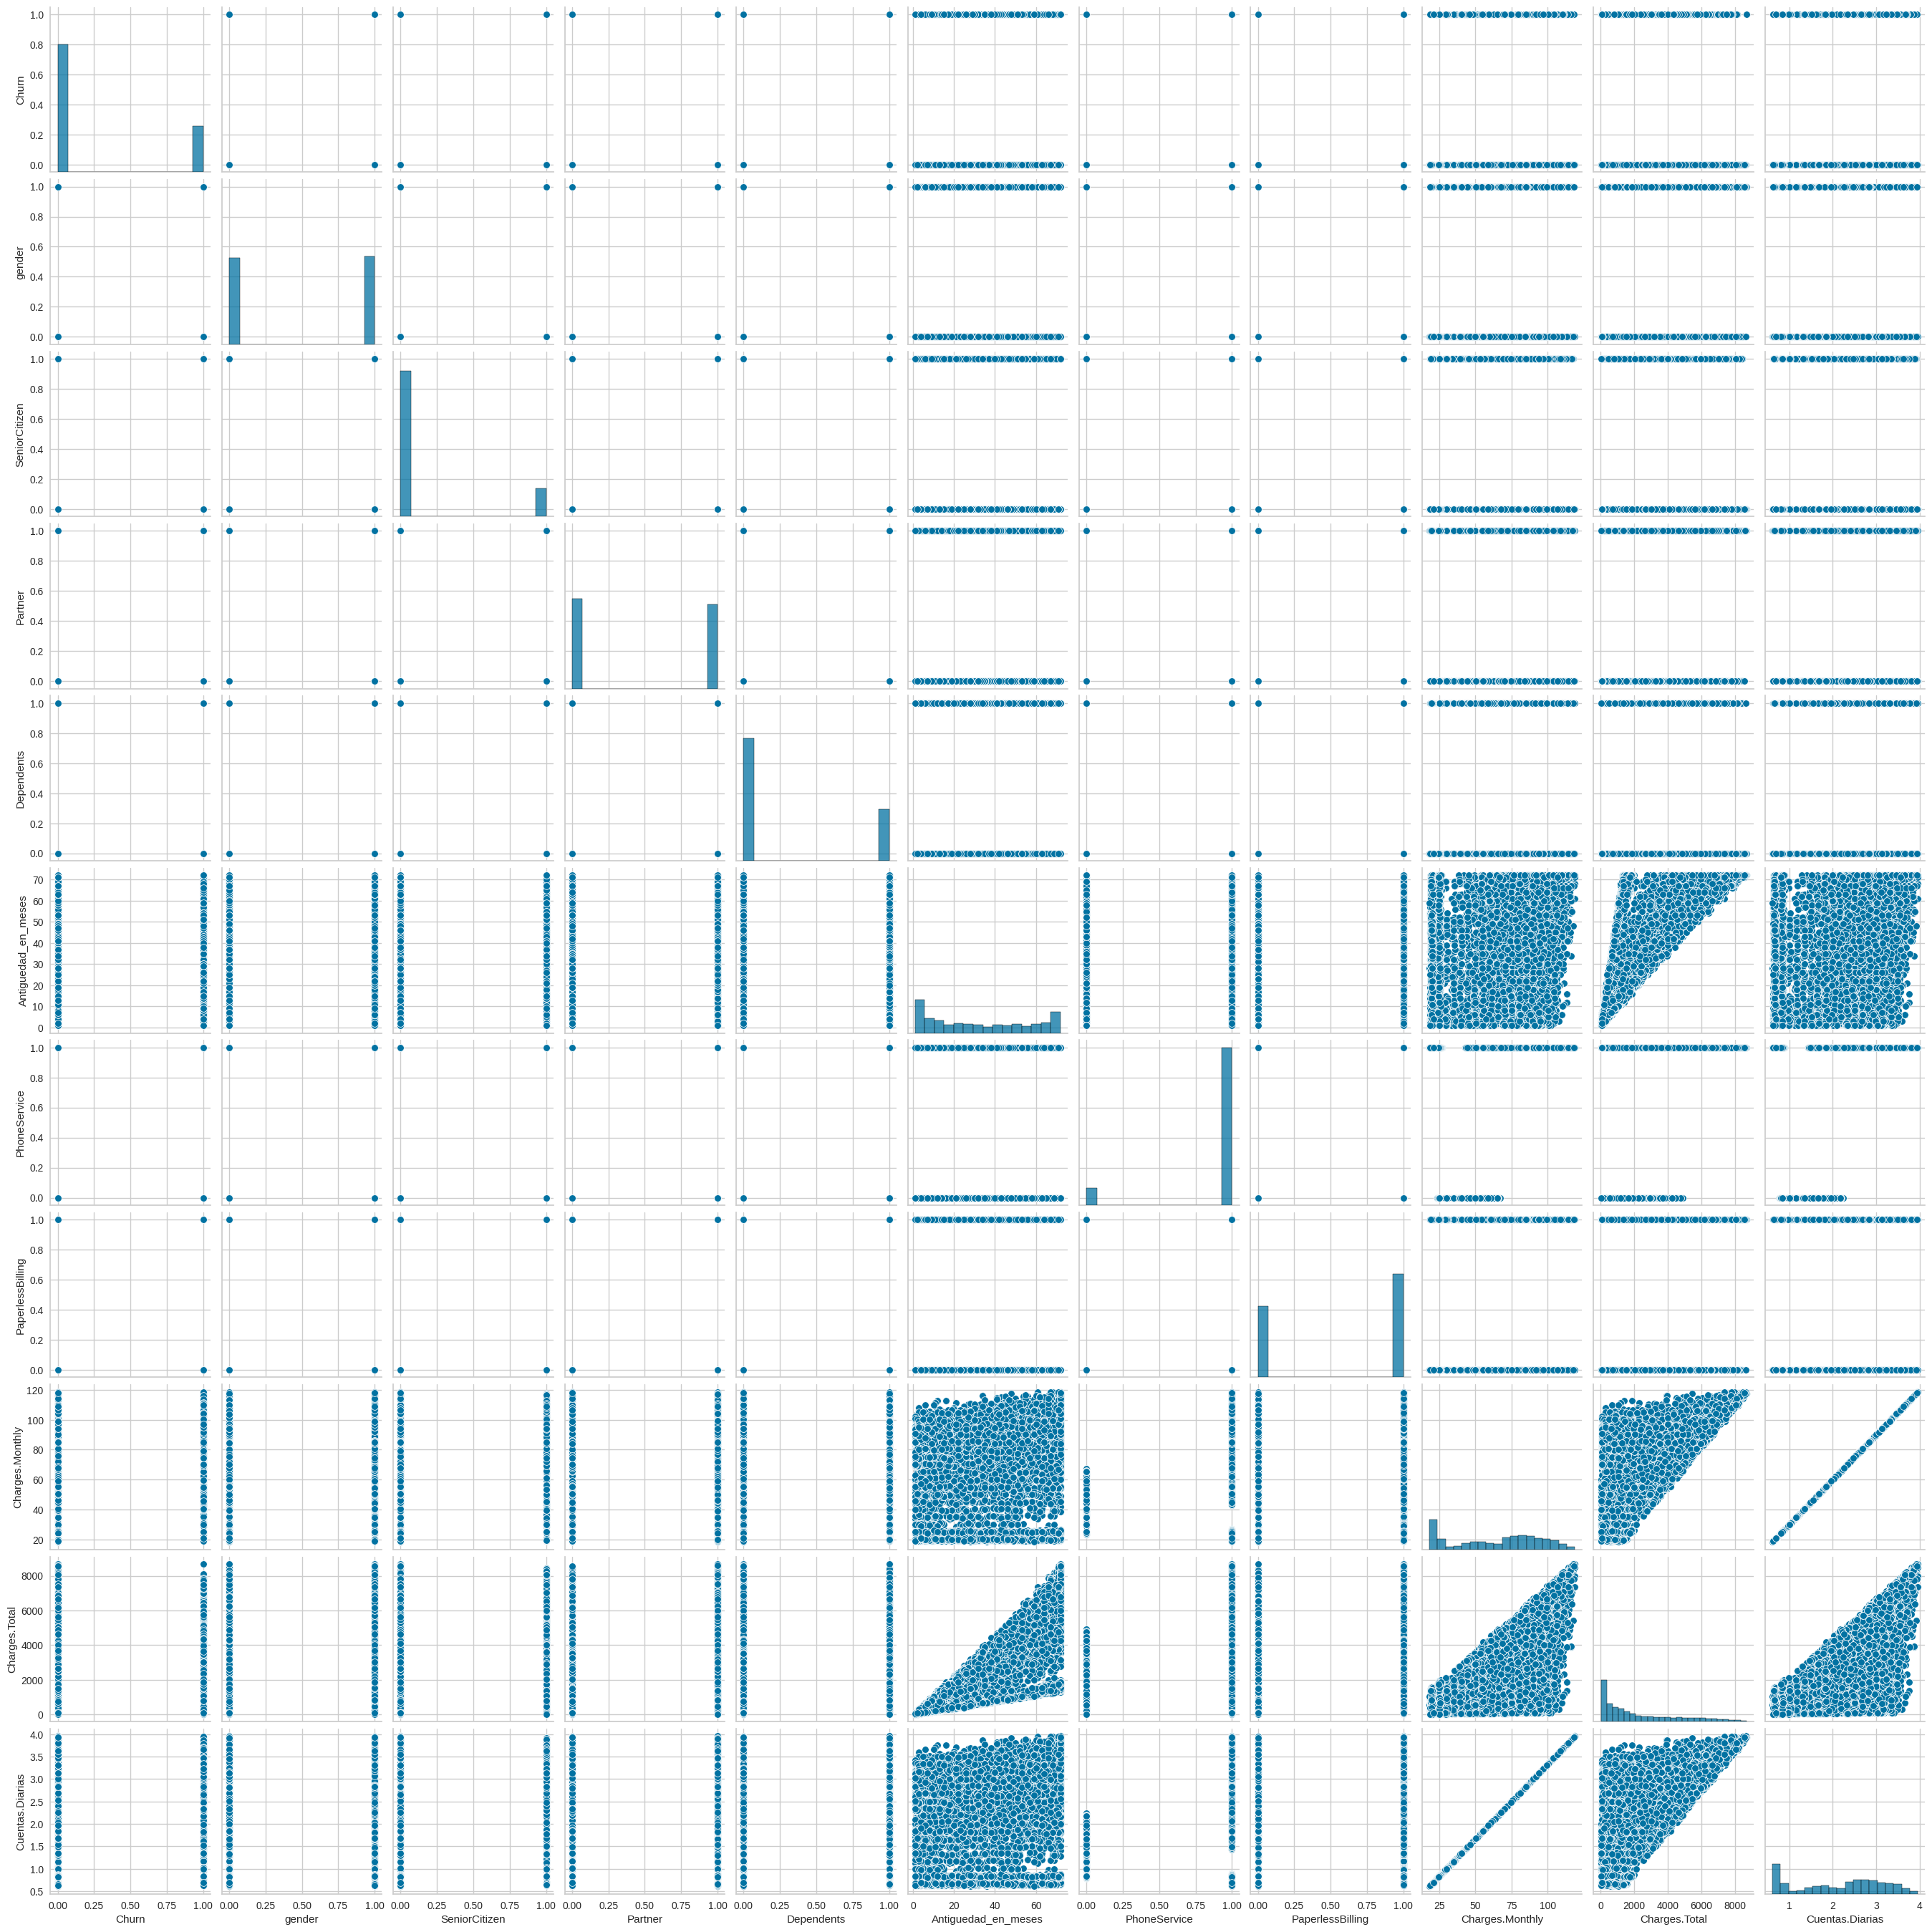

In [ ]:
ax= sns.pairplot(datos)

#Transformacion del tipo de variables

In [ ]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customerID           7032 non-null   object 
 1   Churn                7032 non-null   int64  
 2   gender               7032 non-null   object 
 3   SeniorCitizen        7032 non-null   int64  
 4   Partner              7032 non-null   int64  
 5   Dependents           7032 non-null   int64  
 6   Antiguedad_en_meses  7032 non-null   int64  
 7   PhoneService         7032 non-null   int64  
 8   MultipleLines        7032 non-null   object 
 9   InternetService      7032 non-null   object 
 10  OnlineSecurity       7032 non-null   object 
 11  OnlineBackup         7032 non-null   object 
 12  DeviceProtection     7032 non-null   object 
 13  TechSupport          7032 non-null   object 
 14  StreamingTV          7032 non-null   object 
 15  StreamingMovies      7032 non-null   o

In [ ]:
datos['gender'] = datos['gender'].replace({'Female':0,'Male':1})
datos.head()

/tmp/ipykernel_23288/544066953.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos['gender'] = datos['gender'].replace({'Female':0,'Male':1})


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,Antiguedad_en_meses,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas.Diarias
0,0002-ORFBO,0,0,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,1,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,1,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,1,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,0,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


#CODIFICANDO las variables categoricas

In [ ]:
datos.InternetService.unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [ ]:
datos.Contract.unique()

array(['One year', 'Month-to-month', 'Two year'], dtype=object)

In [ ]:
datos.PaymentMethod.unique()

array(['Mailed check', 'Electronic check', 'Credit card (automatic)',
       'Bank transfer (automatic)'], dtype=object)

Y probamos con todas las variables.

In [ ]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customerID           7032 non-null   object 
 1   Churn                7032 non-null   int64  
 2   gender               7032 non-null   int64  
 3   SeniorCitizen        7032 non-null   int64  
 4   Partner              7032 non-null   int64  
 5   Dependents           7032 non-null   int64  
 6   Antiguedad_en_meses  7032 non-null   int64  
 7   PhoneService         7032 non-null   int64  
 8   MultipleLines        7032 non-null   object 
 9   InternetService      7032 non-null   object 
 10  OnlineSecurity       7032 non-null   object 
 11  OnlineBackup         7032 non-null   object 
 12  DeviceProtection     7032 non-null   object 
 13  TechSupport          7032 non-null   object 
 14  StreamingTV          7032 non-null   object 
 15  StreamingMovies      7032 non-null   o

In [ ]:
categoricas = ['InternetService','Contract','PaymentMethod','MultipleLines', 'OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

In [ ]:
#codificamos estas variables con 0 y 1

pd.get_dummies(data=datos,columns=categoricas,dtype=int).head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,Antiguedad_en_meses,PhoneService,PaperlessBilling,Charges.Monthly,...,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes
0,0002-ORFBO,0,0,0,1,1,9,1,1,65.6,...,0,0,0,1,0,0,1,1,0,0
1,0003-MKNFE,0,1,0,0,0,9,1,0,59.9,...,0,1,0,0,1,0,0,0,0,1
2,0004-TLHLJ,1,1,0,0,0,4,1,1,73.9,...,1,1,0,0,1,0,0,1,0,0
3,0011-IGKFF,1,1,1,1,0,13,1,1,98.0,...,1,1,0,0,0,0,1,0,0,1
4,0013-EXCHZ,1,0,1,1,0,3,1,1,83.9,...,0,0,0,1,0,0,1,1,0,0


In [ ]:
datos_codificados= pd.get_dummies(data=datos,columns=categoricas,dtype=int)
datos_codificados.sample(5)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,Antiguedad_en_meses,PhoneService,PaperlessBilling,Charges.Monthly,...,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes
1327,1976-CFOCS,1,0,1,1,0,1,1,0,46.00,...,0,1,0,0,1,0,0,1,0,0
4387,6199-IPCAO,0,0,0,1,1,29,1,0,26.10,...,0,0,1,0,0,1,0,0,1,0
5519,7786-WBJYI,1,0,0,0,0,4,1,0,77.95,...,0,1,0,0,1,0,0,1,0,0
2786,3973-SKMLN,0,1,0,0,0,71,1,1,19.90,...,0,0,1,0,0,1,0,0,1,0
5704,8050-DVOJX,0,1,1,0,0,49,1,0,81.35,...,1,0,0,1,1,0,0,0,0,1


In [ ]:
datos_codificados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 43 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customerID                               7032 non-null   object 
 1   Churn                                    7032 non-null   int64  
 2   gender                                   7032 non-null   int64  
 3   SeniorCitizen                            7032 non-null   int64  
 4   Partner                                  7032 non-null   int64  
 5   Dependents                               7032 non-null   int64  
 6   Antiguedad_en_meses                      7032 non-null   int64  
 7   PhoneService                             7032 non-null   int64  
 8   PaperlessBilling                         7032 non-null   int64  
 9   Charges.Monthly                          7032 non-null   float64
 10  Charges.Total                            7032 no

de 21 columnas pasamos a 42 pero mas faciles de analizar

#LIMPIANDO LOS DATOS

In [ ]:
datos_codificados.drop(columns=['customerID'],inplace=True)

In [ ]:
datos_codificados.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,Antiguedad_en_meses,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,...,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes
0,0,0,0,1,1,9,1,1,65.6,593.30,...,0,0,0,1,0,0,1,1,0,0
1,0,1,0,0,0,9,1,0,59.9,542.40,...,0,1,0,0,1,0,0,0,0,1
2,1,1,0,0,0,4,1,1,73.9,280.85,...,1,1,0,0,1,0,0,1,0,0
3,1,1,1,1,0,13,1,1,98.0,1237.85,...,1,1,0,0,0,0,1,0,0,1
4,1,0,1,1,0,3,1,1,83.9,267.40,...,0,0,0,1,0,0,1,1,0,0


In [ ]:
datos_codificados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 42 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Churn                                    7032 non-null   int64  
 1   gender                                   7032 non-null   int64  
 2   SeniorCitizen                            7032 non-null   int64  
 3   Partner                                  7032 non-null   int64  
 4   Dependents                               7032 non-null   int64  
 5   Antiguedad_en_meses                      7032 non-null   int64  
 6   PhoneService                             7032 non-null   int64  
 7   PaperlessBilling                         7032 non-null   int64  
 8   Charges.Monthly                          7032 non-null   float64
 9   Charges.Total                            7032 non-null   float64
 10  Cuentas.Diarias                          7032 no

#Evaluando las correlaciones

In [ ]:
datos_codificados.corr()

,Churn,gender,SeniorCitizen,Partner,Dependents,Antiguedad_en_meses,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,...,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes
Churn,1.000000,-0.008545,0.150541,-0.149982,-0.163128,-0.354049,0.011691,0.191454,0.192858,-0.199484,...,-0.066193,0.336877,-0.227578,-0.164716,0.128435,-0.227578,0.063254,0.130920,-0.227578,0.060860
gender,-0.008545,1.000000,-0.001819,-0.001379,0.010349,0.005285,-0.007515,-0.011902,-0.013779,0.000048,...,-0.000807,0.003815,0.004745,-0.008507,0.003088,0.004745,-0.007124,0.006078,0.004745,-0.010105
SeniorCitizen,0.150541,-0.001819,1.000000,0.016957,-0.210550,0.015683,0.008392,0.156258,0.219874,0.102411,...,0.059514,0.205254,-0.182519,-0.060577,0.048664,-0.182519,0.105445,0.034196,-0.182519,0.119842
Partner,-0.149982,-0.001379,0.016957,1.000000,0.452269,0.381912,0.018397,-0.013957,0.097825,0.319072,...,0.153556,-0.108875,-0.000286,0.120206,-0.123394,-0.000286,0.124483,-0.117488,-0.000286,0.118108
Dependents,-0.163128,0.010349,-0.210550,0.452269,1.000000,0.163386,-0.001078,-0.110131,-0.112343,0.064653,...,0.013900,-0.171164,0.138383,0.063053,-0.099912,0.138383,-0.016499,-0.078245,0.138383,-0.038375
Antiguedad_en_meses,-0.354049,0.005285,0.015683,0.381912,0.163386,1.000000,0.007877,0.004823,0.246862,0.825880,...,0.361520,-0.264363,-0.037529,0.325288,-0.246814,-0.037529,0.280264,-0.252890,-0.037529,0.285402
PhoneService,0.011691,-0.007515,0.008392,0.018397,-0.001078,0.007877,1.000000,0.016696,0.248033,0.113008,...,-0.070076,-0.055102,0.171817,-0.095138,-0.123159,0.171817,-0.021383,-0.111273,0.171817,-0.033477
PaperlessBilling,0.191454,-0.011902,0.156258,-0.013957,-0.110131,0.004823,0.016696,1.000000,0.351930,0.157830,...,0.104079,0.229875,-0.320592,0.037536,0.046715,-0.320592,0.224241,0.058987,-0.320592,0.211583
Charges.Monthly,0.192858,-0.013779,0.219874,0.097825,-0.112343,0.246862,0.248033,0.351930,1.000000,0.651065,...,0.482607,0.321267,-0.763191,0.338301,0.016015,-0.763191,0.629668,0.017271,-0.763191,0.627235
Charges.Total,-0.199484,0.000048,0.102411,0.319072,0.064653,0.825880,0.113008,0.157830,0.651065,1.000000,...,0.522881,-0.084270,-0.374878,0.432868,-0.197144,-0.374878,0.515709,-0.202605,-0.374878,0.519867


In [ ]:
correlations = datos_codificados.corr()['Churn'].sort_values(ascending=False)
display(correlations)

,Churn
Churn,1.000000
Contract_Month-to-month,0.404565
OnlineSecurity_No,0.342235
TechSupport_No,0.336877
InternetService_Fiber optic,0.307463
PaymentMethod_Electronic check,0.301455
OnlineBackup_No,0.267595
DeviceProtection_No,0.252056
Cuentas.Diarias,0.192858
Charges.Monthly,0.192858


In [ ]:
datos_codificados[['Churn','Charges.Total','Contract_Month-to-month','Contract_One year','Contract_Two year','Antiguedad_en_meses']].corr()

,Churn,Charges.Total,Contract_Month-to-month,Contract_One year,Contract_Two year,Antiguedad_en_meses
Churn,1.000000,-0.199484,0.404565,-0.178225,-0.301552,-0.354049
Charges.Total,-0.199484,1.000000,-0.446776,0.170569,0.358036,0.825880
Contract_Month-to-month,0.404565,-0.446776,1.000000,-0.570053,-0.621933,-0.649346
Contract_One year,-0.178225,0.170569,-0.570053,1.000000,-0.288843,0.202338
Contract_Two year,-0.301552,0.358036,-0.621933,-0.288843,1.000000,0.563801
Antiguedad_en_meses,-0.354049,0.825880,-0.649346,0.202338,0.563801,1.000000


#DEFINIENDO UNA BASELINE

Estaremos compando los dataos del modelo con este punto de partida

In [ ]:
from sklearn.dummy import DummyRegressor

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x= datos_codificados.drop(['Churn'],axis=1) #todas las columnas menos churn → variables independientes
y= datos_codificados['Churn'] # → variable de respuesta

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=21)

In [ ]:
baseline= DummyRegressor() #creamos nuestro modelo tipo dummy regresor
baseline.fit(x_train,y_train) #entrenamos/ajustamos el modelo

DummyRegressor()

In [ ]:
#vamos a evaluarlo utilizando metricas (que tanto le esta errando)

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


In [ ]:
y_pred_dummy =baseline.predict(x_test)

def calcular_regresion(y_test,y_pred):
    rmse = mean_squared_error(y_test,y_pred)
    mae = mean_absolute_error(y_test,y_pred)
    r2 = r2_score(y_test,y_pred)
    metricas= {
        'RMSE': round(rmse**(1/2),4),
        'MAE': round(mae,4),
        'R2': round(r2,4)
    }
    return metricas


In [ ]:
resultados_baseline= calcular_regresion(y_test,y_pred_dummy)
resultados_baseline

{'RMSE': 0.4369, 'MAE': 0.3879, 'R2': -0.0009}

#Utilizamos ahora el modelo RandomForestRegressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
modelo = RandomForestRegressor( max_depth=5,random_state=21)

In [ ]:
modelo.fit(x_train,y_train)

RandomForestRegressor(max_depth=5, random_state=21)

In [ ]:
ypred=modelo.predict(x_test)

In [ ]:
resultados_rf= calcular_regresion(y_test,ypred)
resultados_rf

{'RMSE': 0.3601, 'MAE': 0.2675, 'R2': 0.3199}

El modelo generalizo mejor

Veamos graficamente como predijo nuesto modelo

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


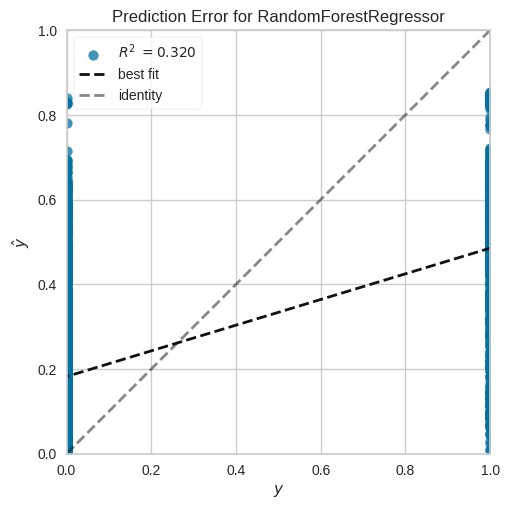

''

In [ ]:
from yellowbrick.regressor import prediction_error

visualizer = prediction_error(modelo, x_train, y_train, x_test, y_test)

;

como se ve aun falta un poco para llegar al mejor ajuste (la recta mas oscura)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


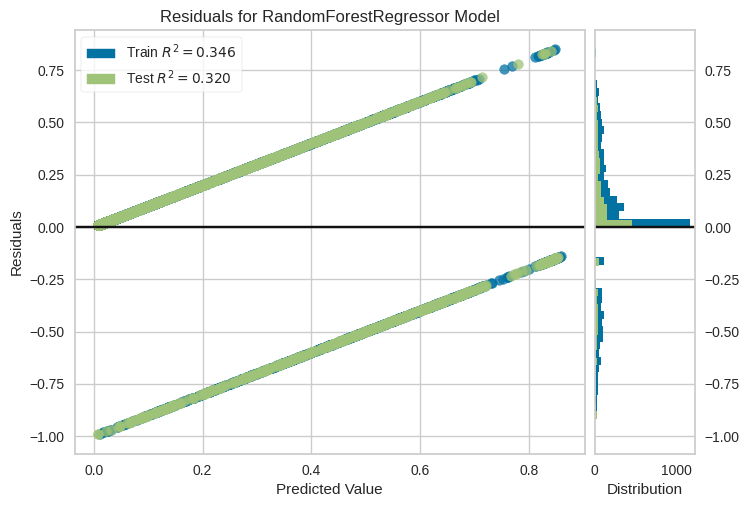

In [ ]:
from yellowbrick.regressor import residuals_plot

viz = residuals_plot(modelo, x_train, y_train, x_test, y_test);

VAMOS A DIVIDIR NUESTRO CONJUNTO DE ENTRENAMIENTO EN VARIAS PARTES (VARIAS DE ENTRENAMIENTO Y UNA DE TEST) Y APARTE EL CONJUNTO DE TEST DATA FINAL


In [ ]:
from sklearn.model_selection import KFold,cross_validate

In [ ]:
cv = KFold(n_splits=5,shuffle=True,random_state=21)

In [ ]:
scoring = {
  'RMSE':'neg_root_mean_squared_error', #usamos esto en version negativa para maximizar el error
  'MAE':'neg_mean_absolute_error',
  'R2':  'r2'
}


cv_results= cross_validate(modelo,x_train,y_train,scoring= scoring,cv=cv)
cv_results

{'fit_time': array([1.94691348, 2.52546811, 1.33184338, 1.7478261 , 1.45678735]),
 'score_time': array([0.06531   , 0.01984644, 0.03049421, 0.03214455, 0.01907349]),
 'test_RMSE': array([-0.37686015, -0.36963115, -0.37635743, -0.37487035, -0.36438758]),
 'test_MAE': array([-0.28341112, -0.2798619 , -0.27912638, -0.28147713, -0.27152964]),
 'test_R2': array([0.28121801, 0.28969955, 0.29020595, 0.30367813, 0.31362573])}

la idea es que haya consistencia en los resultados de los errores, en nuestro caso hubo una variacion muy leve y fueron consistentes entre si



In [ ]:
importances= modelo.feature_importances_
importances

array([1.81920897e-03, 3.41274070e-03, 1.21132534e-03, 2.28859747e-03,
       1.32442428e-01, 5.88936132e-03, 5.37619994e-03, 3.73419203e-02,
       7.85359696e-02, 3.44932543e-02, 1.85673877e-03, 1.07821483e-01,
       0.00000000e+00, 4.79391688e-01, 4.57312145e-03, 4.59084074e-03,
       3.01689498e-04, 1.43525653e-03, 8.28945700e-03, 7.53728021e-04,
       3.50764052e-03, 5.01542209e-03, 1.98230818e-03, 3.79125898e-02,
       2.46952637e-04, 6.08476853e-04, 7.16190917e-03, 3.19909202e-04,
       1.23515119e-03, 1.46278829e-03, 0.00000000e+00, 8.00621748e-04,
       1.51740644e-02, 3.39919919e-04, 2.01837169e-03, 2.48125022e-03,
       0.00000000e+00, 2.58823759e-03, 2.11146872e-03, 3.45335306e-04,
       2.86257437e-03])

In [ ]:
feature_importances =pd.DataFrame({'Feature':x.columns,'Importances':(importances*100).round(2)}).sort_values('Importances',ascending=False)

In [ ]:
feature_importances

,Feature,Importances
13,Contract_Month-to-month,47.94
4,Antiguedad_en_meses,13.24
11,InternetService_Fiber optic,10.78
8,Charges.Total,7.85
23,OnlineSecurity_No,3.79
7,Charges.Monthly,3.73
9,Cuentas.Diarias,3.45
32,TechSupport_No,1.52
18,PaymentMethod_Electronic check,0.83
26,OnlineBackup_No,0.72


Busquemos cuales son los mejores o mas significativas caracteristicas (columnas) para nuestro RandomForestRegressor

In [ ]:
resultados = pd.DataFrame(index=['RMSE','MAE','R2'])
model_features = RandomForestRegressor(max_depth=5,random_state=21)
ct_features = [i if i !=0 else 1 for i in range(0,45,5)]

for i in ct_features:
  selected_features = feature_importances['Feature'].values[:i]
  x_train_sel = x_train[selected_features]
  x_test_sel = x_test[selected_features]
  model_features.fit(x_train_sel,y_train)
  y_pred = model_features.predict(x_test_sel)
  metricas = calcular_regresion(y_test, y_pred)
  resultados[i] = list (metricas.values())

resultados

,1,5,10,15,20,25,30,35,40
RMSE,0.3994,0.3628,0.3610,0.3605,0.3600,0.3601,0.3601,0.3601,0.3602
MAE,0.3219,0.2701,0.2682,0.2675,0.2672,0.2673,0.2675,0.2675,0.2675
R2,0.1632,0.3097,0.3165,0.3185,0.3202,0.3197,0.3197,0.3198,0.3197


podemos ver que hasta 20 features hay mejora, pero dsp se estabiliza

In [ ]:
selected_features = feature_importances['Feature'].values[:20]
x_selected_features = x[selected_features]
x_selected_features

,Contract_Month-to-month,Antiguedad_en_meses,InternetService_Fiber optic,Charges.Total,OnlineSecurity_No,Charges.Monthly,Cuentas.Diarias,TechSupport_No,PaymentMethod_Electronic check,OnlineBackup_No,PhoneService,PaperlessBilling,MultipleLines_No phone service,Contract_Two year,Contract_One year,MultipleLines_No,SeniorCitizen,StreamingMovies_Yes,StreamingTV_Yes,StreamingTV_No
0,0,9,0,593.30,1,65.60,2.186667,0,0,0,1,1,0,0,1,1,0,0,1,0
1,1,9,0,542.40,1,59.90,1.996667,1,0,1,1,0,0,0,0,0,0,1,0,1
2,1,4,1,280.85,1,73.90,2.463333,1,1,1,1,1,0,0,0,1,0,0,0,1
3,1,13,1,1237.85,1,98.00,3.266667,1,1,0,1,1,0,0,0,1,1,1,1,0
4,1,3,1,267.40,1,83.90,2.796667,0,0,1,1,1,0,0,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,13,0,742.90,0,55.15,1.838333,0,0,1,1,0,0,0,1,1,0,0,0,1
7028,1,22,1,1873.70,1,85.10,2.836667,1,1,1,1,1,0,0,0,0,0,1,0,1
7029,1,2,0,92.75,1,50.30,1.676667,1,0,0,1,1,0,0,0,1,0,0,0,1
7030,0,67,0,4627.65,0,67.85,2.261667,0,0,1,1,0,0,1,0,1,0,1,0,1


In [ ]:
resultados = pd.DataFrame(index=['RMSE','MAE','R2'])
model_features = RandomForestRegressor(max_depth=5,random_state=21)
ct_features = range(15,23)

for i in ct_features:
  selected_features = feature_importances['Feature'].values[:i]
  x_train_sel = x_train[selected_features]
  x_test_sel = x_test[selected_features]
  model_features.fit(x_train_sel,y_train)
  y_pred = model_features.predict(x_test_sel)
  metricas = calcular_regresion(y_test, y_pred)
  resultados[i] = list (metricas.values())

resultados

,15,16,17,18,19,20,21,22
RMSE,0.3605,0.3603,0.3602,0.3600,0.3599,0.3600,0.3601,0.3601
MAE,0.2675,0.2674,0.2674,0.2672,0.2671,0.2672,0.2674,0.2673
R2,0.3185,0.3193,0.3196,0.3202,0.3205,0.3202,0.3197,0.3198


tiene sentido que lo dejemos en 18 features

In [ ]:
x_train,x_test,y_train,y_test= train_test_split(x_selected_features,y,random_state=21)

Evaluamos la Cantidad de combinaciones/parametros mas adecuadas para nuestro modelo

In [ ]:
cf = KFold(n_splits=5,shuffle=True,random_state=21)

model_grid = GridSearchCV(RandomForestRegressor(random_state=21), param_grid=param_grid,scoring='r2', cv=cv)


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
 'max_depth': [5, 10, 15],
 'min_samples_leaf': [1, 2, 3],
 'min_samples_split': [2, 4, 6],
 'n_estimators': [100, 150, 200]
 }

model_grid = GridSearchCV(RandomForestRegressor(random_state=21), param_grid=param_grid, cv=3, scoring='r2')
model_grid.fit(x_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=21),
             param_grid={'max_depth': [5, 10, 15],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 4, 6],
                         'n_estimators': [100, 150, 200]},
             scoring='r2')

In [ ]:
model_grid.fit(x_train,y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=21),
             param_grid={'max_depth': [5, 10, 15],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 4, 6],
                         'n_estimators': [100, 150, 200]},
             scoring='r2')

vemos los mejores parametros

In [ ]:
model_grid.best_params_

{'max_depth': 5,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 200}

In [ ]:
y_pred_grid = model_grid.predict(x_test)
metricas_model_grid = calcular_regresion(y_test, y_pred_grid)
metricas_model_grid

{'RMSE': 0.3584, 'MAE': 0.2656, 'R2': 0.3175}

In [ ]:
resultados ['modelo_grid'] = list(metricas_model_grid.values())
resultados


,15,16,17,18,19,20,21,22,modelo_grid
RMSE,0.3605,0.3603,0.3602,0.3600,0.3599,0.3600,0.3601,0.3601,0.3584
MAE,0.2675,0.2674,0.2674,0.2672,0.2671,0.2672,0.2674,0.2673,0.2656
R2,0.3185,0.3193,0.3196,0.3202,0.3205,0.3202,0.3197,0.3198,0.3175
